# trying to run svg model

In [ ]:
import sys

sys.path.append('src/import/SVG/')
sys.path.append('src/import/SVG/autoencoder')

import os
import glob
import torch
from torchvision.utils import save_image
from PIL import Image
from IPython.display import display
from omegaconf import OmegaConf

from rectified_flow.rectified_flow import RectifiedFlow
from utils import instantiate_from_config
from utils import find_model
from ldm.models.dino_decoder import DinoDecoder


In [2]:

torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"


exp_name = 'sanity_check_interpolation'
ckpt_path = "data/V1-SVG-XL-7000K-256x256.pt"
config_path = "src/configs/svg_xl_pretrained_config.yaml"

assert ckpt_path and os.path.exists(ckpt_path), "Please set a valid ckpt_path"
assert config_path and os.path.exists(config_path), "Please set a valid config_path"
print(f"Experiment: {exp_name}")

config = OmegaConf.load(config_path)



Experiment: sanity_check_interpolation


In [3]:

# -------------------------
# 2. Load main model & decoder
# -------------------------
# Load DiT backbone
model = instantiate_from_config(config.model)
state_dict = find_model(ckpt_path)
model.load_state_dict(state_dict, strict=False)
model = model.to(device).eval()


/home/garifzjanovni/non-vae-ldm/venv_vis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loading time: 0.02 seconds
load ema ckpt


In [4]:
# Optional: if you add src/exp/visualizations/extract_svg_features.py and put it on sys.path:
# from extract_svg_features import load_dinov3_encoder
# dinov3 = load_dinov3_encoder(
#     'data/dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth',
#     'src/import/dinov3'
# )
# Load DinoDecoder from encoder config

encoder_config = OmegaConf.load(config.basic.encoder_config)
dinov3 = instantiate_from_config(encoder_config.model).eval()
z_channels = encoder_config.model.params.ddconfig.z_channels


Working with z of shape (1, 392, 16, 16) = 100352 dimensions.
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
Restored from data/svg_autoencoder_dinov3s16p_vit-s_epoch40.ckpt


In [25]:


# -------------------------
# 3. Sampling setup
# -------------------------
seed = 1
torch.manual_seed(seed)

num_steps = 25
cfg_scale = 4
image_size = 256
samples_per_row = 4

# Example class labels (ImageNet indices)
class_labels = [15]#, 270, 284, 688, 250, 146, 980, 484, 207, 20, 387, 974, 88, 979, 417, 279]
n = len(class_labels)

# Initialize latent z
z = torch.randn(2, (image_size // 16) ** 2, z_channels, device=device)


In [ ]:
def interpolate_linear(z: torch.Tensor, steps: int = 10) -> torch.Tensor:
    """
    Linear interpolation between two latent vectors.
    z: (2, seq_len, z_channels)
    returns: (steps, seq_len, z_channels)
    """
    z0, z1 = z[0], z[1]  # each: (seq_len, z_channels)
    ts = torch.linspace(0, 1, steps, device=z.device, dtype=z.dtype)  # (steps,)
    # Broadcast: (steps, 1, 1) * (seq_len, z_channels)
    return (1 - ts[:, None, None]) * z0[None] + ts[:, None, None] * z1[None]


def interpolate_slerp(z: torch.Tensor, steps: int = 10, dot_thr: float = 0.9995) -> torch.Tensor:
    """
    Spherical linear interpolation (SLERP) between two latent vectors.
    z: (2, seq_len, z_channels)
    returns: (steps, seq_len, z_channels)
    """
    z0, z1 = z[0], z[1]  # each: (seq_len, z_channels)
    ts = torch.linspace(0, 1, steps, device=z.device, dtype=z.dtype)  # (steps,)

    # Normalize along z_channels dim
    z0_norm = z0 / torch.norm(z0, dim=-1, keepdim=True)
    z1_norm = z1 / torch.norm(z1, dim=-1, keepdim=True)

    # Dot product per position: (seq_len,)
    dot = (z0_norm * z1_norm).sum(dim=-1).clamp(-1, 1)

    # Angle: (seq_len,)
    theta = torch.acos(dot)  # (seq_len,)

    results = []
    for t in ts:
        # Check for near-parallel vectors per position
        parallel = torch.abs(dot) > dot_thr  # (seq_len,)

        theta_t = theta * t
        sin_theta = torch.sin(theta)

        # Avoid division by zero for parallel vectors
        safe_sin_theta = sin_theta.masked_fill(parallel, 1.0)

        s0 = (torch.sin(theta - theta_t) / safe_sin_theta).unsqueeze(-1)  # (seq_len, 1)
        s1 = (torch.sin(theta_t) / safe_sin_theta).unsqueeze(-1)          # (seq_len, 1)

        slerp_val = s0 * z0 + s1 * z1

        # Fall back to linear for near-parallel positions
        linear_val = (1 - t) * z0 + t * z1
        out = torch.where(parallel.unsqueeze(-1), linear_val, slerp_val)
        results.append(out)

    return torch.stack(results, dim=0)  # (steps, seq_len, z_channels)

def interpolate_slerp_2d_way(z: torch.Tensor, steps: int = 10, dot_thr: float = 0.9995) -> torch.Tensor:
    """
    Spherical linear interpolation (SLERP) between two latent vectors.
    z: (2, num_tokens, z_dim)
    returns: (steps, num_tokens, z_dim)
    """
    z0, z1 = z[0].flatten(), z[1].flatten()  # each: (z_dim,)
    ts = torch.linspace(0, 1, steps, device=z.device, dtype=z.dtype)  # (steps,)

    # Normalize along z_dim
    z0_norm = z0 / torch.norm(z0)
    z1_norm = z1 / torch.norm(z1)

    # Single dot product (scalar)
    dot = (z0_norm * z1_norm).sum().clamp(-1, 1)
    theta = torch.acos(dot)

    parallel = torch.abs(dot) > dot_thr

    results = []
    for t in ts:
        if parallel:
            # Linear fallback
            results.append((1 - t) * z0 + t * z1)
        else:
            sin_theta = torch.sin(theta)
            s0 = torch.sin(theta * (1 - t)) / sin_theta
            s1 = torch.sin(theta * t) / sin_theta
            results.append(s0 * z0 + s1 * z1)

    return torch.stack(results, dim=0).reshape(shape=[steps, -1, z_channels])

In [37]:
test_z = torch.randn(1, (image_size // 16) ** 2, z_channels, device=device)

doubled = test_z.repeat(2, 1, 1)
x10 = test_z.repeat(10, 1, 1)
test_z_l = interpolate_linear(doubled)
test_z_s = interpolate_slerp(doubled)
test_z_s2 = interpolate_slerp_2d_way(doubled)


torch.allclose(test_z_l, x10), torch.allclose(test_z_s, x10), torch.allclose(test_z_s2, x10)

(True, True, True)

In [ ]:
test_z = torch.randn(2, (image_size // 16) ** 2, z_channels, device=device)
test_z_s = interpolate_slerp(z)
test_z_s2 = interpolate_slerp_2d_way(z)

torch.allclose(test_z_s, test_z_s2)

False

In [ ]:
# Load feature normalization stats if applicable
stats_path = "src/import/SVG/dinov3_sp_stats.pt"
assert os.path.exists(stats_path), "Missing dinov3_sp_stats.pt"
stats = torch.load(stats_path)
sp_mean = stats["dinov3_sp_mean"].to(device)[:, :, :z_channels]
sp_std = stats["dinov3_sp_std"].to(device)[:, :, :z_channels]

# CFG and timestep settings
timestep_shift = 0.15
cfg_mode = "constant"
mode = "euler"

y = torch.tensor(class_labels, device=device)
y_null = torch.full_like(y, 1000)

torch.Size([2, 256, 392])
torch.Size([10, 256, 392]) torch.Size([10, 256, 392])


In [33]:

# Load feature normalization stats if applicable
stats_path = "src/import/SVG/dinov3_sp_stats.pt"
assert os.path.exists(stats_path), "Missing dinov3_sp_stats.pt"
stats = torch.load(stats_path)
sp_mean = stats["dinov3_sp_mean"].to(device)[:, :, :z_channels]
sp_std = stats["dinov3_sp_std"].to(device)[:, :, :z_channels]

# CFG and timestep settings
timestep_shift = 0.15
cfg_mode = "constant"
mode = "euler"

y = torch.tensor(class_labels, device=device)
y_null = torch.full_like(y, 1000)


In [34]:

# Run sampling
diffusion = RectifiedFlow(model)
print(f"Sampling with cfg_mode={cfg_mode}, steps={num_steps}, cfg={cfg_scale}")

samples_l = diffusion.sample(
    z_l,
    cond=y,
    null_cond=y_null,
    sample_steps=num_steps,
    cfg=cfg_scale,
    mode=mode,
    timestep_shift=timestep_shift,
    cfg_mode=cfg_mode,
)
samples_s = diffusion.sample(
    z_s,
    cond=y,
    null_cond=y_null,
    sample_steps=num_steps,
    cfg=cfg_scale,
    mode=mode,
    timestep_shift=timestep_shift,
    cfg_mode=cfg_mode,
)

# Apply feature normalization if needed
if config.basic.get("feature_norm", False):
    samples_l = samples_l * sp_std + sp_mean
    samples_s = samples_s * sp_std + sp_mean

# Reshape [B, T, D] -> [B, D, H, W]
B, T, D = samples_l.shape
samples_latent_s = samples_s.permute(0, 2, 1).reshape(B, D, image_size // 16, image_size // 16)
samples_latent_l = samples_l.permute(0, 2, 1).reshape(B, D, image_size // 16, image_size // 16)



Sampling with cfg_mode=constant, steps=25, cfg=4


In [35]:
dinov3 = dinov3.to(device)

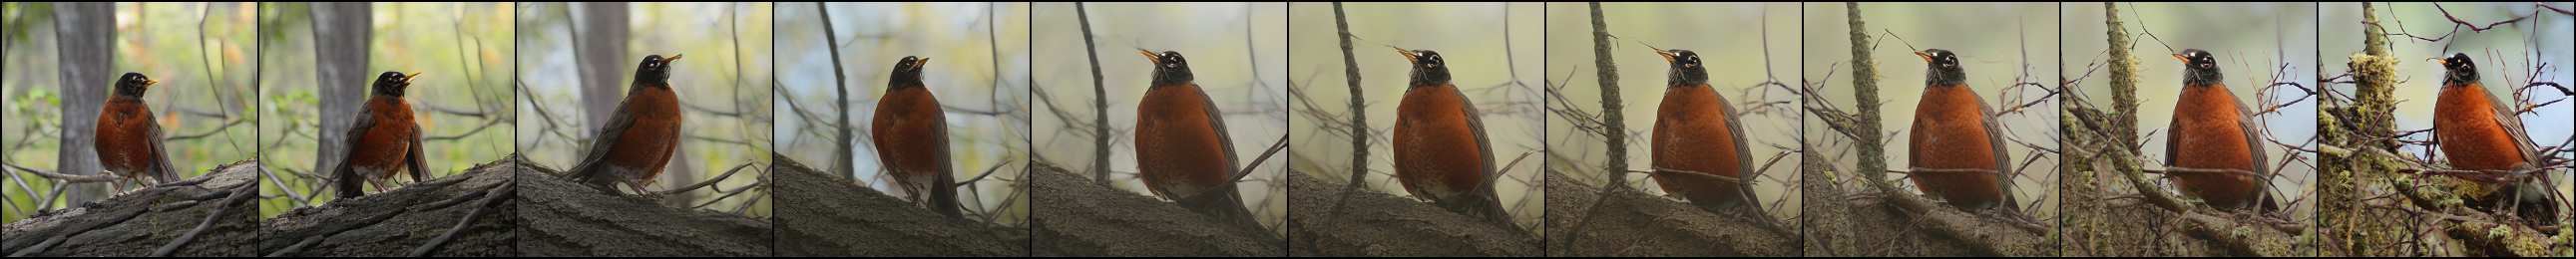

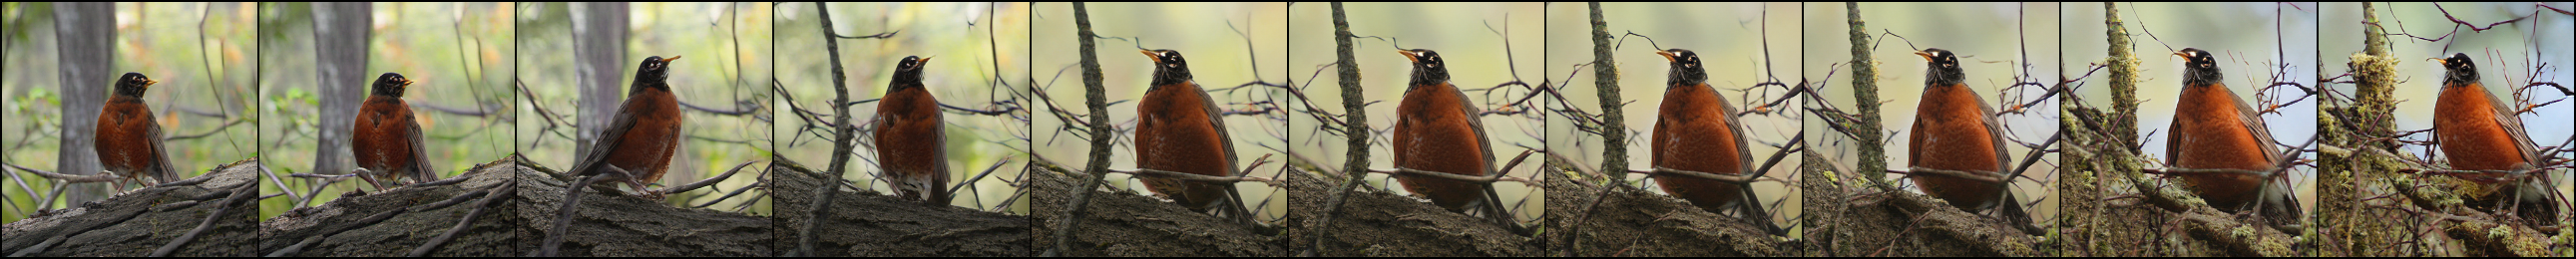

In [36]:

# -------------------------
# 4. Decode to full-resolution images
# -------------------------

with torch.no_grad():
    decoded_full_s = dinov3.decode(samples_latent_s)
    decoded_full_l = dinov3.decode(samples_latent_l)
# print(decoded_full_s.shape)

decoded_full_s = torch.clamp(decoded_full_s, -1, 1)
decoded_full_l = torch.clamp(decoded_full_l, -1, 1)

# Save and visualize
save_path_s = (
    f"{cfg_mode}_sample_{exp_name}_"
    f"steps{num_steps}_{mode}_cfg{cfg_scale}_shift{timestep_shift}_{image_size}_s.png"
)
save_image(decoded_full_s, save_path_s, nrow=decoded_full_s.shape[0], normalize=True, value_range=(-1, 1))
save_path_l = (
    f"{cfg_mode}_sample_{exp_name}_"
    f"steps{num_steps}_{mode}_cfg{cfg_scale}_shift{timestep_shift}_{image_size}_l.png"
)
save_image(decoded_full_l, save_path_l, nrow=decoded_full_l.shape[0], normalize=True, value_range=(-1, 1))
display(Image.open(save_path_s))
display(Image.open(save_path_l))

# print(f"Saved results to {save_path}")


In [ ]:
# torch.save(decoded_full_l, "torch_" + save_path_l.replace('.png', '.pt'), pickle_protocol=4)
# torch.save(decoded_full_s, "torch_" + save_path_s.replace('.png', '.pt'), pickle_protocol=4)

tensor([[[[True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          ...,
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True]],

         [[True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          ...,
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True]],

         [[True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          ...,
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ...

In [10]:
with open('data/imgnet100/classes.txt', 'r') as f:
    my_classes = f.read().split('\n')[:-1]

len(my_classes), my_classes[:5], my_classes[-5:]

(100,
 ['African hunting dog, hyena dog, Cape hunting dog, Lycaon pictus',
  'American Staffordshire terrier, Staffordshire terrier, American pit bull terrier, pit bull terrier',
  'American coot, marsh hen, mud hen, water hen, Fulica americana',
  'American lobster, Northern lobster, Maine lobster, Homarus americanus',
  'Chesapeake Bay retriever'],
 ['vizsla, Hungarian pointer',
  'walking stick, walkingstick, stick insect',
  'wild boar, boar, Sus scrofa',
  'window screen',
  'wing'])

In [ ]:

import json
import urllib.request

# Download the standard mapping file
url = "https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/imagenet_class_index.json"
with urllib.request.urlopen(url) as f:
    class_index = json.load(f)

with open('data/imagenet_class_index.json', 'w+') as f:
    json.dump(class_index, f, indent=4)

# Invert: label string -> index
label_to_idx = {v[1]: int(k) for k, v in class_index.items()}
idx_to_label = {int(k): v[1] for k, v in class_index.items()}


In [28]:

# Your list of class strings
# my_classes = ['Doberman, Doberman pinscher', 'goldfish']

# Lookup — try each comma-separated synonym
def get_index(label_str):
    results = []
    for part in label_str.split(','):
        part = '_'.join(part.strip().split())
        if part in label_to_idx:
            results.append(label_to_idx[part])
    return results

not_found = []
for cls in my_classes:
    idx = get_index(cls)
    if not idx:
        not_found.append(cls)
    elif len(idx) > 1:   
        print(cls, '->', idx)



chime, bell, gong -> [494, 577]
harmonica, mouth organ, harp, mouth harp -> [593, 594]


In [26]:
get_index('cat')

[]